# RECS Data Preprocessing

**Purpose.** Load and preprocess RECS data; create modeling-ready features and targets.

**Inputs.** Raw RECS dataset files placed in `data/` (adjust file names/paths in the notebook).

**Outputs.** Processed dataset saved to `outputs/` (and/or `data/processed/` if configured).

**Reproducibility.** Set a random seed and keep paths configurable (see `Configuration` cell below).

**Notes.** Absolute paths were removed; edit only the Configuration cell for portability.


In [1]:
# Configuration (edit paths here)
from pathlib import Path
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

import warnings
warnings.simplefilter(action='ignore')

import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Project root (defaults to the folder containing this notebook)
PROJECT_ROOT = Path(r"./01_RECS_national")

# Data / artifacts
DATA_DIR = PROJECT_ROOT / "03_Outcomes" / "01-Processed_Datasets"
MODEL_DIR = PROJECT_ROOT / "03_Outcomes" / "02-Models"
FIG_DIR = PROJECT_ROOT / "03_Outcomes" / "03_Figures"
SHAP_DIR = PROJECT_ROOT / "03_Outcomes" / "04_shap"

for _d in [DATA_DIR, MODEL_DIR, FIG_DIR, SHAP_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)


PROJECT_ROOT: .\01_RECS_national
DATA_DIR: .\01_RECS_national\03_Outcomes\01-Processed_Datasets


### Read and load datasets

In [2]:
df_recs_raw = pd.read_csv( PROJECT_ROOT / "01_Data" /"Processed data"/ "recs2020_allstates.csv" )
df_recs_raw.info()
df_recs_raw.head()

<class 'pandas.DataFrame'>
RangeIndex: 18496 entries, 0 to 18495
Columns: 292 entries, DOEID to TOTALBTU
dtypes: float64(12), int64(279), str(1)
memory usage: 41.2 MB


,DOEID,IECC_climate_code,HDD65,CDD65,HDD30YR_PUB,CDD30YR_PUB,TYPEHUQ,CELLAR,CRAWL,CONCRETE,...,ENERGYASST19,ENERGYASST18,ENERGYASST17,ENERGYASST16,ENERGYASSTOTH,SQFTEST,DBT1,DBT99,GWT,TOTALBTU
0,100001,4B,3844,1679,4451,1027,2,0,0,1,...,-2,-2,-2,-2,-2,2100,92.9,21.6,58.5,144647.71
1,100002,4A,3766,1458,4429,1305,5,-2,-2,-2,...,-2,-2,-2,-2,-2,590,91.3,16.1,57.2,28034.61
2,100003,4B,3819,1696,4500,1010,5,-2,-2,-2,...,-2,-2,-2,-2,-2,900,92.9,21.6,58.5,30749.71
3,100004,3A,2614,1718,3229,1653,2,0,1,0,...,-2,-2,-2,-2,-2,2100,91.8,25.1,61.5,86765.19
4,100005,4A,4219,1363,4896,1059,5,-2,-2,-2,...,-2,-2,-2,-2,-2,800,81.8,13.0,55.9,59126.93


## **Preprocess Dataset**
Rule for preprocessing: 
| Category type           | Encoding       |
| ----------------------- | -------------- |
| Binary (0/1)            | keep as is     |
| Nominal (3+ categories) | one-hot        |
| Ordinal                 | ordinal encode |
| Numeric                 | keep numeric   |

#### **Variable groups**

In [4]:
# base variable groups
num_cols_base = ["TVONWD3","TVONWE3","HDD65","CDD65","HDD30YR_PUB","CDD30YR_PUB","BEDROOMS","NCOMBATH",
                 "NHAFBATH","OTHROOMS","TOTROOMS","DOOR1SUM","MONPOOL","MONTUB","NUMFRIG","NUMFREEZ",
                 "RANGE","COOKTOP","OVEN","RCOOKUSE","ROVENUSE","COOKTOPUSE","OVENUSE","MICRO","AMTMICRO",
                 "DWASHUSE","WASHLOAD","DRYRUSE","TVCOLOR","TVONWD1","TVONWE1","TVONWD2","TVONWE2",
                 "CABLESAT","COMBODVR","SEPDVR","INTSTREAM","PLAYSTA","DVD","VCR","TVAUDIOSYS","DESKTOP",
                 "NUMLAPTOP","NUMTABLET","ELPERIPH","NUMSMPHONE","CELLPHONE","TELLDAYS","SMARTSPK",
                 "NUMPORTEL","NUMFIREPLC","NUMDLHP","NUMPORTHUM","NUMDLHPAC","NUMWWAC","NUMPORTAC",
                 "NUMCFAN","NUMFLOORFAN","NUMPORTDEHUM","TEMPHOME","TEMPGONE","TEMPNITE","TEMPHOMEAC",
                 "TEMPGONEAC","TEMPNITEAC","LGTIN1TO4","LGTIN4TO8","LGTINMORE8","LGTOUTNITE","HHAGE",
                 "NHSLDMEM","NUMCHILD","NUMADULT1","NUMADULT2","ATHOME","NOHEATDAYS","NOACDAYS","SQFTEST",
                 "DBT1","DBT99","GWT"]

bin_cols_base = ["CELLAR","CRAWL","CONCRETE","BASEOTH","BASEFIN","ATTIC","ATTICFIN","PRKGPLC1","STUDIO",
                 "HIGHCEIL","ORIGWIN","TREESHAD","UGASHERE","SWIMPOOL","POOLPUMP","RECBATH","ICE","WINECHILL",
                 "RANGEINDT","COOKTOPINDT","OUTGRILL","TOAST","TOASTOVN","CROCKPOT","PRSSCOOK","RICECOOK",
                 "BLENDER","APPOTHER","ELFOOD","LPCOOK","UGCOOK","DISHWASH","CWASHER","DRYER","TELLWORK",
                 "TLDESKTOP","TLLAPTOP","TLTABLET","TLMONITOR","TLOTHER","ONLNEDUC","INTYPECELL","INTYPEBROAD",
                 "INTYPEOTH","SSLIGHT","SSTEMP","SSSECURE","SSTV","SSOTHER","HEATHOME","HEATAPT","GEOHP",
                 "EQUIPAUX","BASEHEAT","ATTCHEAT","GARGHEAT","ELWARM","UGWARM","LPWARM","FOWARM","WDWARM",
                 "AIRCOND","COOLAPT","BASECOOL","ATTCCOOL","GARGCOOL","HOUSEFAN","ATTICFAN","ELCOOL","H2OAPT",
                 "WHEATBKT","MORETHAN1H2O","ELWATER","FOWATER","LPWATER","SOLWATER","WDWATER","UGWATER",
                 "LGTOUTANY","LGTOUTLED","LGTOUTCFL","LGTOUTCAN","SMARTMETER","INTDATAACC","MEDICALDEV",
                 "POWEROUT","BACKUP","SOLAR","OUTLET","ELECVEH","EVCHRGHOME","UGOTH","LPOTHER","FOOTHER",
                 "USEEL","USENG","USELP","USEFO","USESOLAR","USEWOOD","ALLELEC","SDESCENT","PAYHELP",
                 "NOHEATBROKE","NOHEATEL","NOHEATNG","NOHEATBULK","NOHEATHELP","COLDMA","NOACBROKE","NOACEL",
                 "NOACHELP","HOTMA","ENERGYASST","ENERGYASST20","ENERGYASST19","ENERGYASST18","ENERGYASST17",
                 "ENERGYASST16","ENERGYASSTOTH"]

ord_cols_base = ["YEARMADERANGE","WINDOWS","ADQINSUL","DRAFTY","SIZRFRI1","AGERFRI1","SIZRFRI2","AGERFRI2",
                 "SIZFREEZ","AGEFRZR","NUMMEAL","USECOFFEE","AGEDW","AGECWASH","AGECDRYER","TVSIZE1","TVSIZE2",
                 "TVSIZE3","EQUIPAGE","USEEQUIPAUX","USEHUMID","ACEQUIPAGE","USECFAN","USEDEHUM","WHEATSIZ",
                 "WHEATAGE","LGTINLED","LGTINCFL","LGTINCAN","MONEYPY","SCALEB","SCALEG","SCALEE","STORIES",
                 "SIZEOFGARAGE"]

nom_cols_base= ["IECC_climate_code","TYPEHUQ","KOWNRENT","WALLTYPE","ROOFTYPE","TYPEGLASS","WINFRAME","FUELPOOL",
                "FUELTUB","TYPERFR1","TYPERFR2","LOCRFRI2","UPRTFRZR","FREEZER","RANGEFUEL","COOKTOPFUEL",
                "OVENFUEL","OUTGRILLFUEL","DWCYCLE","TOPFRONT","WASHTEMP","DRYRFUEL","TVTYPE1","TVUSE1",
                "TVTYPE2","TVUSE2","TVTYPE3","TVUSE3","INTERNET","DNTHEAT","EQUIPM","FUELHEAT","EQUIPAUXTYPE",
                "FUELAUX","HUMIDTYPE","ACEQUIPM_PUB","ACEQUIPAUXTYPE_PUB","DEHUMTYPE","TYPETHERM","HEATCNTL",
                "COOLCNTL","H2OMAIN","FUELH2O","FUELH2O2","ELPAY","NGPAY","LPGPAY","FOPAY","WHYPOWEROUT","HHSEX",
                "EMPLOYHH","EDUCATION","HOUSEHOLDER_RACE"]


### **Droping Constant Features: Using Variance Selection**
(can only be used for numerical data. So, the encoding must be done before using the variance selection method.)

In [14]:
### It will zero variance features

df_num_cols_base = df_recs_raw[num_cols_base]
df_bin_cols_base = df_recs_raw[bin_cols_base]
df_ord_cols_base = df_recs_raw[ord_cols_base]

from sklearn.feature_selection import VarianceThreshold

var_thres=VarianceThreshold(threshold=0)
var_thres.fit(df_num_cols_base)

var_thres.get_support()

constant_columns_numeric = [column for column in df_num_cols_base.columns
                    if column not in df_num_cols_base.columns[var_thres.get_support()]]

print(len(constant_columns_numeric))

for feature in constant_columns_numeric:
     print(feature)

0


In [15]:
from sklearn.feature_selection import VarianceThreshold

var_thres=VarianceThreshold(threshold=0)
var_thres.fit(df_bin_cols_base)

var_thres.get_support()

constant_columns_binary = [column for column in df_bin_cols_base.columns
                    if column not in df_bin_cols_base.columns[var_thres.get_support()]]

print(len(constant_columns_binary))

for feature in constant_columns_binary:
     print(feature)

1
USEEL


In [16]:
from sklearn.feature_selection import VarianceThreshold

var_thres=VarianceThreshold(threshold=0)
var_thres.fit(df_ord_cols_base)

var_thres.get_support()

constant_columns_ordinal = [column for column in df_ord_cols_base.columns
                    if column not in df_ord_cols_base.columns[var_thres.get_support()]]

print(len(constant_columns_ordinal))

for feature in constant_columns_ordinal:
     print(feature)

0


### **Encoding categorical variables**
* Low cardinality → One-Hot Encoding
* High cardinality → Frequency Encoding

**keeps special codes (-2, 99) as categories.**

In [5]:
# Frequency encoding function

def frequency_encode(df, cols):
    df = df.copy()
    for col in cols:
        freq = df[col].value_counts(normalize=True)
        df[col + "_freq"] = df[col].map(freq)
        df.drop(columns=[col], inplace=True)
    return df

# One-hot encoding function
def one_hot_encode(df, cols):
    df = pd.get_dummies(
        df,
        columns=cols,
        prefix=cols,
        dtype=int
    )
    return df

In [6]:
def split_cardinality(df, cols, threshold=15):

    low_card_cols = []
    high_card_cols = []

    for col in cols:
        if col not in df.columns:
            continue
        n_unique = df[col].nunique()

        if n_unique <= threshold:
            low_card_cols.append(col)
        else:
            high_card_cols.append(col)
    return low_card_cols, high_card_cols

In [7]:
def preprocess_nominal(df, nominal_cols, threshold=15):

    df = df.copy()

    # ensure categorical dtype
    for col in nominal_cols:
        if col in df.columns:
            df[col] = df[col].astype("string")

    # split by cardinality
    low_cols, high_cols = split_cardinality(df, nominal_cols, threshold)

    # apply encoding
    df = one_hot_encode(df, low_cols)
    df = frequency_encode(df, high_cols)

    return df, low_cols, high_cols

In [8]:
df_nominal = df_recs_raw[nom_cols_base]
df_nominal.info()

df_nominal_clean, low_card_cols, high_card_cols = preprocess_nominal(
    df_nominal,
    nom_cols_base,
    threshold=15
)

df_nominal_clean.info()
df_nominal_clean.to_csv(PROJECT_ROOT / "03_Outcomes" / "01-Processed_Datasets"/"df_nominal_clean.csv", index=True)

<class 'pandas.DataFrame'>
RangeIndex: 18496 entries, 0 to 18495
Data columns (total 53 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   IECC_climate_code   18496 non-null  str  
 1   TYPEHUQ             18496 non-null  int64
 2   KOWNRENT            18496 non-null  int64
 3   WALLTYPE            18496 non-null  int64
 4   ROOFTYPE            18496 non-null  int64
 5   TYPEGLASS           18496 non-null  int64
 6   WINFRAME            18496 non-null  int64
 7   FUELPOOL            18496 non-null  int64
 8   FUELTUB             18496 non-null  int64
 9   TYPERFR1            18496 non-null  int64
 10  TYPERFR2            18496 non-null  int64
 11  LOCRFRI2            18496 non-null  int64
 12  UPRTFRZR            18496 non-null  int64
 13  FREEZER             18496 non-null  int64
 14  RANGEFUEL           18496 non-null  int64
 15  COOKTOPFUEL         18496 non-null  int64
 16  OVENFUEL            18496 non-null  int64
 17  OUTG

In [9]:
df_nominal_clean.head()

,TYPEHUQ_1,TYPEHUQ_2,TYPEHUQ_3,TYPEHUQ_4,TYPEHUQ_5,KOWNRENT_1,KOWNRENT_2,KOWNRENT_3,WALLTYPE_1,WALLTYPE_2,...,EDUCATION_3,EDUCATION_4,EDUCATION_5,HOUSEHOLDER_RACE_1,HOUSEHOLDER_RACE_2,HOUSEHOLDER_RACE_3,HOUSEHOLDER_RACE_4,HOUSEHOLDER_RACE_5,HOUSEHOLDER_RACE_6,IECC_climate_code_freq
0,0,1,0,0,0,1,0,0,1,0,...,0,0,1,1,0,0,0,0,0,0.007731
1,0,0,0,0,1,0,1,0,1,0,...,1,0,0,1,0,0,0,0,0,0.221399
2,0,0,0,0,1,0,1,0,1,0,...,0,1,0,1,0,0,0,0,0,0.007731
3,0,1,0,0,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0.116782
4,0,0,0,0,1,0,1,0,0,0,...,0,0,1,1,0,0,0,0,0,0.221399


### **Droping Constant Nominal Features: Using Variance Selection**
(can only be used for numerical data. So, the encoding must be done before using the variance selection method.)

In [12]:
### It will zero variance features
from sklearn.feature_selection import VarianceThreshold

var_thres=VarianceThreshold(threshold=0)
var_thres.fit(df_nominal_clean)

var_thres.get_support()

constant_columns_nominal = [column for column in df_nominal_clean.columns
                    if column not in df_nominal_clean.columns[var_thres.get_support()]]

print(len(constant_columns_nominal))

for feature in constant_columns_nominal:
     print(feature)

0


### **Clean numeric variables**

In [37]:
# pure numeric variables: keep as is.
num_cols_pure = [
"HDD65","CDD65","HDD30YR_PUB","CDD30YR_PUB",
"BEDROOMS","NCOMBATH","NHAFBATH","OTHROOMS","TOTROOMS",
"DOOR1SUM","NUMFRIG","NUMFREEZ","RANGE","COOKTOP","OVEN","MICRO",
"TVCOLOR","DESKTOP","NUMLAPTOP","NUMTABLET","ELPERIPH",
"NUMSMPHONE","CELLPHONE",
"NUMCFAN","NUMFLOORFAN",
"LGTIN1TO4","LGTIN4TO8","LGTINMORE8",
"HHAGE","NHSLDMEM","NUMCHILD","NUMADULT1","NUMADULT2",
"SQFTEST","DBT1","DBT99","GWT"
]

# special codes: "-2": structural clean
num_cols_structural = [
"TVONWD3","TVONWE3","TVONWD1","TVONWE1","TVONWD2","TVONWE2",
"MONPOOL","MONTUB",
"RCOOKUSE","ROVENUSE","COOKTOPUSE","OVENUSE",
"AMTMICRO","DWASHUSE","WASHLOAD","DRYRUSE",
"CABLESAT","COMBODVR","SEPDVR","INTSTREAM","PLAYSTA","DVD","VCR","TVAUDIOSYS",
"TELLDAYS","SMARTSPK",
"NUMPORTEL","NUMFIREPLC","NUMDLHP","NUMPORTHUM","NUMDLHPAC","NUMWWAC","NUMPORTAC","NUMPORTDEHUM",
"TEMPHOME","TEMPGONE","TEMPNITE","TEMPHOMEAC","TEMPGONEAC","TEMPNITEAC",
"LGTOUTNITE",
"NOHEATDAYS","NOACDAYS"
]

In [38]:
df_num_structural = df_recs_raw[num_cols_structural]
df_num_structural.info()

<class 'pandas.DataFrame'>
RangeIndex: 18496 entries, 0 to 18495
Data columns (total 43 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TVONWD3       18496 non-null  float64
 1   TVONWE3       18496 non-null  float64
 2   TVONWD1       18496 non-null  float64
 3   TVONWE1       18496 non-null  float64
 4   TVONWD2       18496 non-null  float64
 5   TVONWE2       18496 non-null  float64
 6   MONPOOL       18496 non-null  int64  
 7   MONTUB        18496 non-null  int64  
 8   RCOOKUSE      18496 non-null  int64  
 9   ROVENUSE      18496 non-null  int64  
 10  COOKTOPUSE    18496 non-null  int64  
 11  OVENUSE       18496 non-null  int64  
 12  AMTMICRO      18496 non-null  int64  
 13  DWASHUSE      18496 non-null  int64  
 14  WASHLOAD      18496 non-null  int64  
 15  DRYRUSE       18496 non-null  int64  
 16  CABLESAT      18496 non-null  int64  
 17  COMBODVR      18496 non-null  int64  
 18  SEPDVR        18496 non-null  int64  

In [39]:
# convert numeric
def convert_numeric(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def clean_structural_numeric(df, cols):
    for col in cols:
        if col in df.columns:
            df[col + "_exist"] = (df[col] != -2).astype(int)
            df[col] = df[col].replace(-2, 0)
    return df
    
# Structural numeric cleaner
def preprocess_numeric(df):
    df = df.copy()

    # convert numeric columns
    df = convert_numeric(df, num_cols_structural + num_cols_pure)

    # process structural numeric variables
    df = clean_structural_numeric(df, num_cols_structural)

    return df

# Process structural numeric variables
df_num_structural_clean = preprocess_numeric(df_num_structural)

df_num_structural_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 18496 entries, 0 to 18495
Data columns (total 86 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TVONWD3             18496 non-null  float64
 1   TVONWE3             18496 non-null  float64
 2   TVONWD1             18496 non-null  float64
 3   TVONWE1             18496 non-null  float64
 4   TVONWD2             18496 non-null  float64
 5   TVONWE2             18496 non-null  float64
 6   MONPOOL             18496 non-null  int64  
 7   MONTUB              18496 non-null  int64  
 8   RCOOKUSE            18496 non-null  int64  
 9   ROVENUSE            18496 non-null  int64  
 10  COOKTOPUSE          18496 non-null  int64  
 11  OVENUSE             18496 non-null  int64  
 12  AMTMICRO            18496 non-null  int64  
 13  DWASHUSE            18496 non-null  int64  
 14  WASHLOAD            18496 non-null  int64  
 15  DRYRUSE             18496 non-null  int64  
 16  CABLESAT       

In [40]:
df_num_pure = df_recs_raw[num_cols_pure]
df_num_clean = pd.concat(
    [df_num_structural_clean, df_num_pure],
    axis=1
)
df_num_clean.info()
df_num_clean.to_csv(PROJECT_ROOT / "03_Outcomes" / "01-Processed_Datasets"/"df_num_clean.csv", index=True)

<class 'pandas.DataFrame'>
RangeIndex: 18496 entries, 0 to 18495
Columns: 123 entries, TVONWD3 to GWT
dtypes: float64(9), int64(114)
memory usage: 17.4 MB


In [71]:
df_num_clean.head()

,TVONWD3,TVONWE3,TVONWD1,TVONWE1,TVONWD2,TVONWE2,MONPOOL,MONTUB,RCOOKUSE,ROVENUSE,...,LGTINMORE8,HHAGE,NHSLDMEM,NUMCHILD,NUMADULT1,NUMADULT2,SQFTEST,DBT1,DBT99,GWT
0,0.5,0.5,4.0,6.0,5.0,5.0,0,0,21,10,...,3,65,2,0,0,2,2100,92.9,21.6,58.5
1,0.0,0.0,3.0,3.0,0.0,0.0,0,0,7,2,...,2,79,1,0,0,1,590,91.3,16.1,57.2
2,0.0,0.0,5.0,5.0,0.0,0.0,0,0,2,1,...,0,82,1,0,0,1,900,92.9,21.6,58.5
3,0.0,0.0,8.0,8.0,4.0,4.0,0,0,12,0,...,1,70,2,0,0,2,2100,91.8,25.1,61.5
4,0.0,0.0,5.0,6.0,1.0,2.0,0,0,18,0,...,4,30,2,0,2,0,800,81.8,13.0,55.9


### **Encode ordinal variables**
* -2 → Not applicable, existence indicator
* 99 → Other, separate category
* 0 values are valid categories (e.g., Never)
* WHEATSIZ: “4 Tankless/on-demand” → 0
* Preserve ordinal ordering for the remaining categories

In [45]:
def preprocess_ordinal(df, ordinal_cols):

    df = df.copy()

    for col in ordinal_cols:

        if col not in df.columns:
            continue

        # ensure numeric
        df[col] = pd.to_numeric(df[col], errors="coerce")

        # indicator for structural NA (-2)
        df[col + "_exists"] = (df[col] != -2).astype(int)

        # indicator for "other" category (99)
        df[col + "_other"] = (df[col] == 99).astype(int)

        # replace structural codes with neutral value
        df[col] = df[col].replace({-2: 0, 99: 0})

            # --- special handling for STORIES ---
        if col == "STORIES":

            # split-level indicator
            df["STORIES_split"] = (df[col] == 5).astype(int)

            # remove split-level from ordinal scale
            df.loc[df[col] == 5, col] = 0

        # remove structural codes from ordinal scale
        df[col] = df[col].replace({-2: 0, 99: 0})
    
    # special rule: WHEATSIZ tankless category
    if "WHEATSIZ" in df.columns:
        df["WHEATSIZ"] = df["WHEATSIZ"].replace(4, 0)

    return df

In [46]:
df_ord_raw = df_recs_raw [ord_cols_base]
df_ord_raw.info()

df_ord_clean = preprocess_ordinal(df_ord_raw, ord_cols_base)
df_ord_clean.info()

df_ord_clean.to_csv(PROJECT_ROOT / "03_Outcomes" / "01-Processed_Datasets"/"df_ord_clean.csv", index=True)

<class 'pandas.DataFrame'>
RangeIndex: 18496 entries, 0 to 18495
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   YEARMADERANGE  18496 non-null  int64
 1   WINDOWS        18496 non-null  int64
 2   ADQINSUL       18496 non-null  int64
 3   DRAFTY         18496 non-null  int64
 4   SIZRFRI1       18496 non-null  int64
 5   AGERFRI1       18496 non-null  int64
 6   SIZRFRI2       18496 non-null  int64
 7   AGERFRI2       18496 non-null  int64
 8   SIZFREEZ       18496 non-null  int64
 9   AGEFRZR        18496 non-null  int64
 10  NUMMEAL        18496 non-null  int64
 11  USECOFFEE      18496 non-null  int64
 12  AGEDW          18496 non-null  int64
 13  AGECWASH       18496 non-null  int64
 14  AGECDRYER      18496 non-null  int64
 15  TVSIZE1        18496 non-null  int64
 16  TVSIZE2        18496 non-null  int64
 17  TVSIZE3        18496 non-null  int64
 18  EQUIPAGE       18496 non-null  int64
 19  USEEQUIPAUX    

In [73]:
df_ord_clean.head()

,YEARMADERANGE,WINDOWS,ADQINSUL,DRAFTY,SIZRFRI1,AGERFRI1,SIZRFRI2,AGERFRI2,SIZFREEZ,AGEFRZR,...,SCALEB_other,SCALEG_exists,SCALEG_other,SCALEE_exists,SCALEE_other,STORIES_exists,STORIES_other,STORIES_split,SIZEOFGARAGE_exists,SIZEOFGARAGE_other
0,4,4,2,3,4,3,3,3,4,5,...,0,1,0,1,0,1,0,0,1,0
1,5,1,2,3,3,1,0,0,1,1,...,0,1,0,1,0,0,0,0,0,0
2,3,1,2,4,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
3,5,5,2,4,4,3,2,3,0,0,...,0,1,0,1,0,1,0,0,1,0
4,3,1,2,3,4,3,1,1,0,0,...,0,1,0,1,0,0,0,0,0,0


### **Clean binary variables**

In [47]:
df_bin_raw = df_recs_raw[bin_cols_base]
df_bin_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 18496 entries, 0 to 18495
Columns: 120 entries, CELLAR to ENERGYASSTOTH
dtypes: float64(2), int64(118)
memory usage: 16.9 MB


In [48]:
def preprocess_binary(df, binary_cols):

    df = df.copy()

    for col in binary_cols:

        df[col] = pd.to_numeric(df[col], errors="coerce")

        # existence indicator
        df[col + "_exists"] = 1
        df.loc[df[col] == -2, col + "_exists"] = 0

        # replace -2 with 0 in binary column
        df.loc[df[col] == -2, col] = 0

    return df

In [49]:
df_bin_clean = preprocess_binary(df_bin_raw, bin_cols_base)
df_bin_clean.info()
df_bin_clean.to_csv(PROJECT_ROOT / "03_Outcomes" / "01-Processed_Datasets"/"df_binary_clean.csv", index=True)

<class 'pandas.DataFrame'>
RangeIndex: 18496 entries, 0 to 18495
Columns: 240 entries, CELLAR to ENERGYASSTOTH_exists
dtypes: float64(2), int64(238)
memory usage: 33.9 MB


In [74]:
df_bin_clean.head()

,CELLAR,CRAWL,CONCRETE,BASEOTH,BASEFIN,ATTIC,ATTICFIN,PRKGPLC1,STUDIO,HIGHCEIL,...,NOACEL_exists,NOACHELP_exists,HOTMA_exists,ENERGYASST_exists,ENERGYASST20_exists,ENERGYASST19_exists,ENERGYASST18_exists,ENERGYASST17_exists,ENERGYASST16_exists,ENERGYASSTOTH_exists
0,0,0,1,0,0,0,0,1,0,0,...,1,0,1,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,...,1,0,1,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,1,0,1,1,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,1,...,1,0,1,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,1,0,1,1,0,0,0,0,0,0


### **Final clean datasets**

In [76]:
df_recs_clean = pd.concat(
    [df_num_clean, df_nominal_clean, df_ord_clean, df_bin_clean],
    axis=1
)

df_recs_clean.info()

df_recs_clean.to_csv(PROJECT_ROOT / "03_Outcomes" / "01-Processed_Datasets"/"df_recs_clean.csv", index=False)

<class 'pandas.DataFrame'>
RangeIndex: 18496 entries, 0 to 18495
Columns: 750 entries, TVONWD3 to ENERGYASSTOTH_exists
dtypes: Float64(1), float64(11), int64(738)
memory usage: 105.9 MB


In [77]:
df_recs_clean.head()

,TVONWD3,TVONWE3,TVONWD1,TVONWE1,TVONWD2,TVONWE2,MONPOOL,MONTUB,RCOOKUSE,ROVENUSE,...,NOACEL_exists,NOACHELP_exists,HOTMA_exists,ENERGYASST_exists,ENERGYASST20_exists,ENERGYASST19_exists,ENERGYASST18_exists,ENERGYASST17_exists,ENERGYASST16_exists,ENERGYASSTOTH_exists
0,0.5,0.5,4.0,6.0,5.0,5.0,0,0,21,10,...,1,0,1,1,0,0,0,0,0,0
1,0.0,0.0,3.0,3.0,0.0,0.0,0,0,7,2,...,1,0,1,1,0,0,0,0,0,0
2,0.0,0.0,5.0,5.0,0.0,0.0,0,0,2,1,...,1,0,1,1,0,0,0,0,0,0
3,0.0,0.0,8.0,8.0,4.0,4.0,0,0,12,0,...,1,0,1,1,0,0,0,0,0,0
4,0.0,0.0,5.0,6.0,1.0,2.0,0,0,18,0,...,1,0,1,1,0,0,0,0,0,0


### **Handle missing values**

In [78]:
# Function to calculate missing values by column
def missing_values_table(df_recs_clean):
        # Total missing values
        mis_val = df_recs_clean.isnull().sum()

        # Percentage of missing values
        mis_val_percent = 100 * df_recs_clean.isnull().sum() / len(df_recs_clean)

        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})

        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

        # Print some summary information
        print ("Your selected dataframe has " + str(df_recs_clean.shape[1]) + " columns.\n"
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")

        # Return the dataframe with missing information
        return mis_val_table_ren_columns

missing_values_table(df_recs_clean)

Your selected dataframe has 750 columns.
There are 2 columns that have missing values.


,Missing Values,% of Total Values
MEDICALDEV,210,1.1
EVCHRGHOME,11,0.1


In [79]:
# Apply missing indicator imputation
def apply_missing_indicator_imputation(df):

    df = df.copy()

    # Identify columns with missing values
    missing_cols = df.columns[df.isnull().any()]

    for col in missing_cols:

        # create missing indicator
        df[col + "_missing"] = df[col].isna().astype(int)

        # fill missing values with 0
        df[col] = df[col].fillna(0)

    return df

In [80]:
# Missing Indicator Imputation
df_recs_clean = apply_missing_indicator_imputation(df_recs_clean)
missing_values_table(df_recs_clean)

Your selected dataframe has 752 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


In [81]:
### It will zero variance features
from sklearn.feature_selection import VarianceThreshold

var_thres=VarianceThreshold(threshold=0)
var_thres.fit(df_recs_clean)

var_thres.get_support()

constant_columns_recs = [column for column in df_recs_clean.columns
                    if column not in df_recs_clean.columns[var_thres.get_support()]]

print(len(constant_columns_recs))

110


In [82]:
for feature in constant_columns_recs:
     print(feature)

YEARMADERANGE_exists
YEARMADERANGE_other
WINDOWS_exists
WINDOWS_other
ADQINSUL_exists
ADQINSUL_other
DRAFTY_exists
DRAFTY_other
SIZRFRI1_other
AGERFRI1_other
SIZRFRI2_other
AGERFRI2_other
SIZFREEZ_other
AGEFRZR_other
NUMMEAL_exists
NUMMEAL_other
USECOFFEE_exists
USECOFFEE_other
AGEDW_other
AGECWASH_other
AGECDRYER_other
TVSIZE1_other
TVSIZE2_other
TVSIZE3_other
EQUIPAGE_other
USEEQUIPAUX_other
ACEQUIPAGE_other
WHEATSIZ_exists
WHEATSIZ_other
WHEATAGE_exists
WHEATAGE_other
LGTINLED_exists
LGTINLED_other
LGTINCFL_exists
LGTINCFL_other
LGTINCAN_exists
LGTINCAN_other
MONEYPY_exists
MONEYPY_other
SCALEB_exists
SCALEB_other
SCALEG_exists
SCALEG_other
SCALEE_exists
SCALEE_other
STORIES_other
SIZEOFGARAGE_other
USEEL
ORIGWIN_exists
TREESHAD_exists
UGASHERE_exists
RECBATH_exists
WINECHILL_exists
OUTGRILL_exists
TOAST_exists
TOASTOVN_exists
CROCKPOT_exists
PRSSCOOK_exists
RICECOOK_exists
BLENDER_exists
APPOTHER_exists
ELFOOD_exists
LPCOOK_exists
UGCOOK_exists
DISHWASH_exists
CWASHER_exists
DRYER_

### **Process target variable, energy use (BTU)**

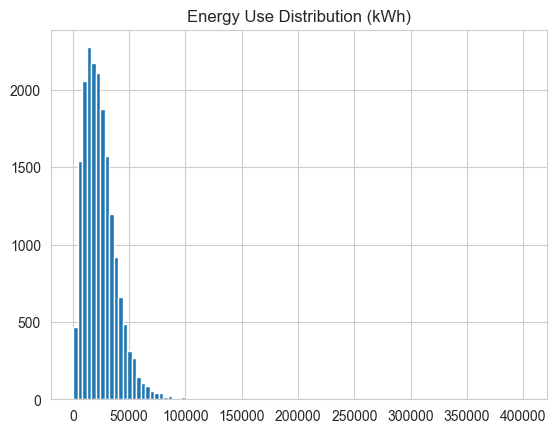

In [93]:
col_target = "TOTALKWH"
              
df_recs_processed = df_recs_clean.copy()
df_recs_processed['TOTALKWH'] = df_recs_raw['TOTALBTU']* 0.293071

df_recs_processed[col_target].hist(bins=100)
plt.title("Energy Use Distribution (kWh)")
plt.show()

In [94]:
df_recs_processed[col_target].describe(percentiles=[0.01,0.05,0.95,0.99])

count     18496.000000
mean      24325.565131
std       15593.134161
min         346.474398
1%         3085.878053
5%         5773.010004
95%       51277.511873
99%       73668.032673
max      400788.698007
Name: TOTALKWH, dtype: float64

In [95]:
lower = df_recs_processed[col_target].quantile(0.01)
upper = df_recs_processed[col_target].quantile(0.99)

df_recs_processed[df_recs_processed[col_target] > upper]

,TVONWD3,TVONWE3,TVONWD1,TVONWE1,TVONWD2,TVONWE2,MONPOOL,MONTUB,RCOOKUSE,ROVENUSE,...,ENERGYASST_exists,ENERGYASST20_exists,ENERGYASST19_exists,ENERGYASST18_exists,ENERGYASST17_exists,ENERGYASST16_exists,ENERGYASSTOTH_exists,MEDICALDEV_missing,EVCHRGHOME_missing,TOTALKWH
184,0.5,0.5,8.0,8.0,2.0,2.0,5,5,10,8,...,1,0,0,0,0,0,0,0,0,85366.512172
293,4.0,5.0,16.0,18.0,2.0,2.0,6,3,0,0,...,1,0,0,0,0,0,0,0,0,98761.248959
513,12.0,12.0,10.0,12.0,6.0,8.0,5,5,0,0,...,1,0,0,0,0,0,0,0,0,98600.177137
634,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,86710.784888
692,2.0,2.0,10.0,10.0,4.0,7.0,5,7,10,5,...,1,0,0,0,0,0,0,0,0,116847.310987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17671,3.0,3.0,5.0,5.0,5.0,5.0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,88930.777198
17929,0.5,0.5,10.0,8.0,0.5,0.5,0,0,0,0,...,1,0,0,0,0,0,0,0,0,100707.723966
18312,0.0,0.0,4.0,6.0,0.5,2.0,0,0,10,6,...,1,0,0,0,0,0,0,0,0,92842.026566
18332,3.0,2.0,4.0,4.0,5.0,10.0,4,12,0,0,...,1,0,0,0,0,0,0,0,0,78626.972327


In [96]:
# log transform energy use
df_recs_processed["energy_kwh_log"] = np.log1p(df_recs_processed[col_target])
df_recs_processed.head()

df_recs_processed.to_csv(PROJECT_ROOT / "03_Outcomes" / "01-Processed_Datasets"/"df_recs_processed.csv", index=False)

### **Define X, y variable**

In [97]:
# target variable is "energy_kwh_log"
X_recs_clean = df_recs_clean
y_recs_clean = df_recs_processed['energy_kwh_log']

print(y_recs_clean.describe())

count    18496.000000
mean         9.898509
std          0.674373
min          5.850691
25%          9.499633
50%          9.986957
75%         10.367519
max         12.901192
Name: energy_kwh_log, dtype: float64


### **Tain Test split**
random_state fixes randomness ensures reproducible results 42 is just a popular convention

In [98]:
# split dataset into train and test (80/20)
from sklearn.model_selection import train_test_split

X_train_recs_clean, X_test_recs_clean, y_train_recs_clean, y_test_recs_clean = train_test_split(
    X_recs_clean,
    y_recs_clean,
    test_size=0.2,
    random_state=42)
    # A fixed random seed (42) was used to ensure reproducibility.

X_train_recs_clean.shape, X_test_recs_clean.shape

((14796, 752), (3700, 752))

### **Scaling**

In [99]:
# scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_recs_clean)
X_test_scaled  = scaler.transform(X_test_recs_clean)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(14796, 752)
(3700, 752)


In [100]:
# save the final processed DataFrame to a CSV file
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_recs_clean.columns,
    index=X_train_recs_clean.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_recs_clean.columns,
    index=X_test_recs_clean.index
)

X_train_scaled.to_csv(PROJECT_ROOT / "03_Outcomes" / "01-Processed_Datasets"/ "X_train_scaled.csv", index=False)
X_test_scaled.to_csv(PROJECT_ROOT / "03_Outcomes" / "01-Processed_Datasets"/"X_test_scaled.csv", index=False)

y_train_recs_clean.to_csv(PROJECT_ROOT / "03_Outcomes" / "01-Processed_Datasets"/"y_train.csv", index=False)
y_test_recs_clean.to_csv(PROJECT_ROOT / "03_Outcomes" / "01-Processed_Datasets"/"y_test.csv", index=False)

In [101]:
# Save the Scaler
import joblib
scaler_path = PROJECT_ROOT / "03_Outcomes" / "01-Processed_Datasets" / "scaler_recs.pkl"
joblib.dump(scaler, scaler_path)

['.\\01_RECS_national\\03_Outcomes\\01-Processed_Datasets\\scaler_recs.pkl']